# Quantum Key Distribution (Without Eavesdropper)

## Imports

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.primitives import BackendSamplerV2

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

## Quantum  Circuit

In [17]:
# Set up a random number generator and a quantum circuit. I choose to start with 20 bits, though any number <30 should be fine.

rng = np.random.default_rng()
bit_num = 20
qc = QuantumCircuit(bit_num, bit_num)

# QKD step 1: Random bits and bases for Alice
# generate Alice's random bits

abits = np.round(rng.random(bit_num))

# generate Alice's random measurement bases. Here we will associate a "0" with the Z basis, and a "1" with the X basis.

abase = np.round(rng.random(bit_num))

# Alice's state preparation. Check that this creates states according to table 1

for n in range(bit_num):
    if abits[n] == 0:
        if abase[n] == 1:
            qc.h(n)
    if abits[n] == 1:
        if abase[n] == 0:
            qc.x(n)
        if abase[n] == 1:
            qc.x(n)
            qc.h(n)

qc.barrier()

# QKD step 2: Random bases for Bob
# generate Bob's random measurement bases.

bbase = np.round(rng.random(bit_num))

# Note that if Bob measures in Z no gates are necessary, since IBM Quantum computers measure in Z by default.
# If Bob measures in the X basis, we implement a hadamard gate qc.h to facilitate the measurement.

for m in range(bit_num):
    if bbase[m] == 1:
        qc.h(m)
    qc.measure(m, m)

Alice's bits are  [0. 1. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1.]
Alice's bases are  [0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1.]
Bob's bases are  [0. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0.]


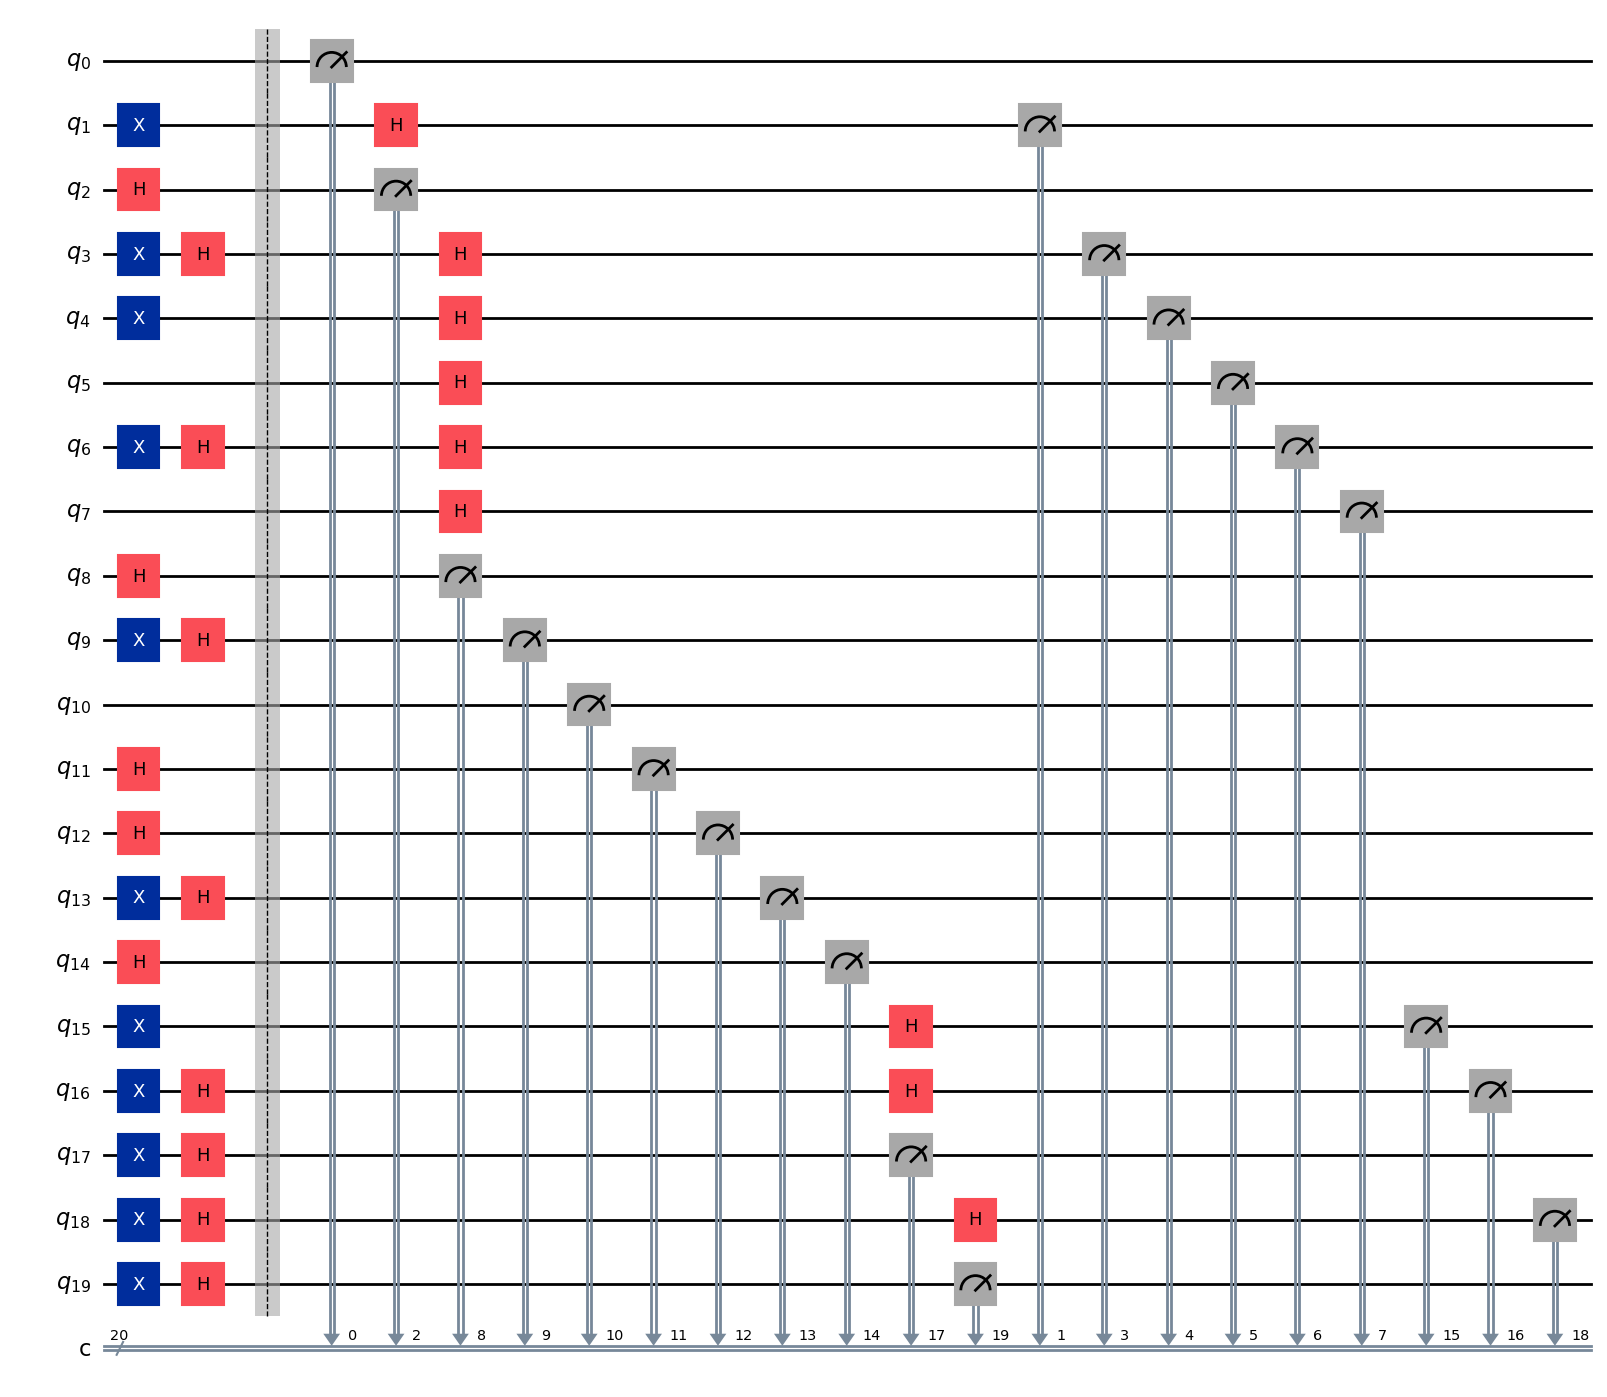

In [18]:
print("Alice's bits are ", abits)
print("Alice's bases are ", abase)
print("Bob's bases are ", bbase)
qc.draw("mpl")

## Optimize problem for quantum execution

In [20]:
# Load saved credentials
service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)

print(backend.name)

ibm_fez


In [23]:
noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

In [24]:
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

## Execute

In [25]:
sampler = Sampler(mode=backend)
# job = sampler.run([qc_isa], shots=1)
job = sampler_sim.run([qc], shots = 1)
counts = job.result()[0].data.c.get_counts()
countsint = job.result()[0].data.c.get_int_counts()

##  Post-processing

In [26]:
# Get an array of bits

keys = counts.keys()
key = list(keys)[0]
bmeas = list(key)
bmeas_ints = []
for n in range(bit_num):
    bmeas_ints.append(int(bmeas[n]))

# Reverse the order to match our input. See "little endian" notation.

bbits = bmeas_ints[::-1]

print(bbits)

[0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1]


Let's compare the measurement bases randomly chosen by Alice and Bob. This was step 3 in our QKD protocol (public discussion of bases). Any time they chose the same basis for a qubit, we add the bits associated with that qubit to a list of bits for generating numbers in a one-time pad. When the bases do not match, the results are thrown out. Let us also check to see the two lists of bits agree, or if there were any losses due to noise or other factors.

In [27]:
# QKD step 3: Public discussion of bases

agoodbits = []
bgoodbits = []
match_count = 0
for n in range(bit_num):
    # Check whether bases matched.
    if abase[n] == bbase[n]:
        agoodbits.append(int(abits[n]))
        bgoodbits.append(bbits[n])
        # If bits match when bases matched, increase count of matching bits
        if int(abits[n]) == bbits[n]:
            match_count += 1

print(agoodbits)
print(bgoodbits)
print("fidelity = ", match_count / len(agoodbits))
print("loss = ", 1 - match_count / len(agoodbits))

[0, 1, 1, 0, 1, 1]
[0, 1, 1, 0, 1, 1]
fidelity =  1.0
loss =  0.0


Source: https://quantum.cloud.ibm.com/learning/en/modules/computer-science/quantum-key-distribution